<a href="https://www.kaggle.com/code/lalit7881/campaign-performance-dataset-v2?scriptVersionId=301346372" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/nykaa_campaign_data.csv
/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/purplle_campaign_data.csv
/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/tira_campaign_data.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/purplle_campaign_data.csv")

In [3]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,PU-CMP-1000,Paid Ads,Working Women,6,"Facebook, Google",31869,3490,1946,902,493394,55.93,8.78,Tamil,19.89,Premium Shoppers,27-12-2024
1,PU-CMP-1001,Paid Ads,Premium Shoppers,8,"Instagram, WhatsApp",26640,2441,741,314,108644,197.44,0.75,Bengali,13.12,Premium Shoppers,26-11-2024
2,PU-CMP-1002,Influencer,Youth,22,"Facebook, WhatsApp",36967,4997,1025,653,238345,234.59,0.56,English,18.06,College Students,08-01-2025
3,PU-CMP-1003,Paid Ads,Youth,15,"Instagram, WhatsApp",73258,5893,2565,1970,1341570,103.76,5.56,Bengali,14.23,College Students,14-03-2025
4,PU-CMP-1004,Social Media,Premium Shoppers,11,"WhatsApp, Instagram",91081,6393,3282,2582,787510,78.61,2.88,English,13.46,College Students,11-07-2024


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [5]:
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.492323,55065.619296,4682.537629,1870.449932,1028.283107,5.137314e+05,376.660244,2.682922,13.756615
std,7.494224,25968.772947,3178.892846,1430.942807,857.789716,4.882659e+05,534.308147,4.479447,6.332377
min,5.000000,10001.000000,207.000000,48.000000,19.000000,6.061000e+03,9.340000,-0.970000,2.560000
25%,11.000000,32589.500000,2111.000000,779.000000,400.000000,1.769570e+05,107.225000,0.040000,8.350000
50%,17.000000,55120.000000,3903.000000,1471.000000,774.000000,3.580200e+05,209.630000,1.230000,13.570000
75%,24.000000,77677.500000,6706.000000,2593.000000,1403.000000,6.861095e+05,430.125000,3.560000,18.780000
max,30.000000,100000.000000,14888.000000,8613.000000,6221.000000,4.345920e+06,12109.050000,66.840000,30.990000


In [6]:
df.isnull().sum()

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

Campaign_ID          object
Campaign_Type        object
Target_Audience      object
Duration              int64
Channel_Used         object
Impressions           int64
Clicks                int64
Leads                 int64
Conversions           int64
Revenue               int64
Acquisition_Cost    float64
ROI                 float64
Language             object
Engagement_Score    float64
Customer_Segment     object
Date                 object
dtype: object

In [9]:
df.shape

(55555, 16)

In [10]:
df.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date'],
      dtype='object')

In [11]:
df.nunique()

Campaign_ID         55555
Campaign_Type           5
Target_Audience         5
Duration               26
Channel_Used          156
Impressions         41295
Clicks              12114
Leads                6294
Conversions          4165
Revenue             49341
Acquisition_Cost    37524
ROI                  2493
Language                4
Engagement_Score     2665
Customer_Segment        5
Date                  359
dtype: int64

## EDA

In [12]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

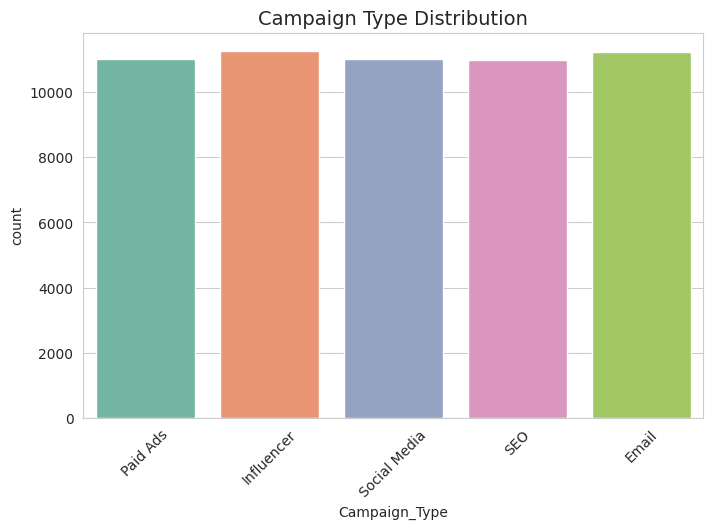

In [13]:
plt.figure()
sns.countplot(x="Campaign_Type", data=df, palette="Set2")
plt.title("Campaign Type Distribution", fontsize=14)
plt.xticks(rotation=45)
plt.show()

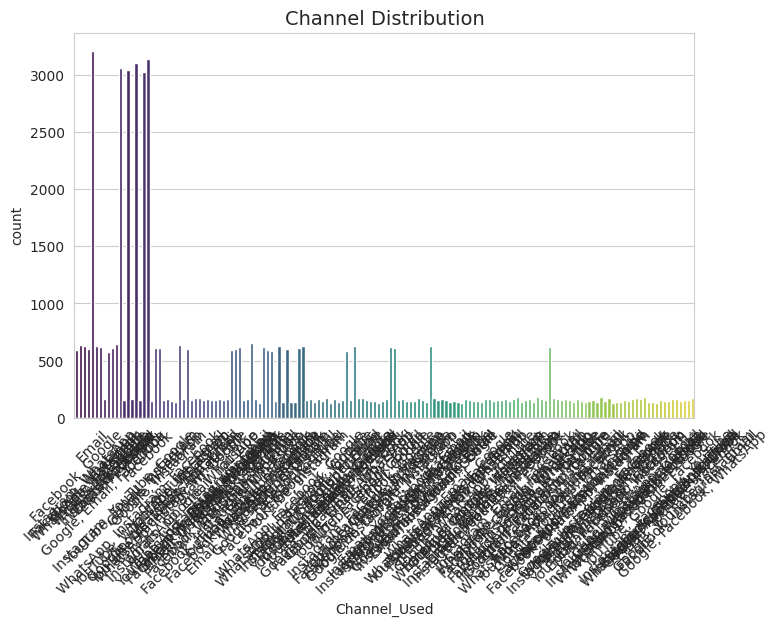

In [14]:
plt.figure()
sns.countplot(x="Channel_Used", data=df, palette="viridis")
plt.title("Channel Distribution", fontsize=14)
plt.xticks(rotation=45)
plt.show()

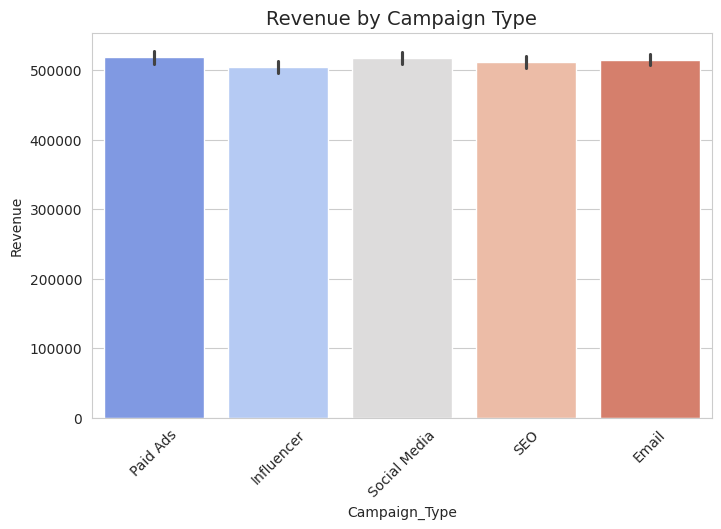

In [15]:
plt.figure()
sns.barplot(x="Campaign_Type", y="Revenue", data=df, palette="coolwarm")
plt.title("Revenue by Campaign Type", fontsize=14)
plt.xticks(rotation=45)
plt.show()

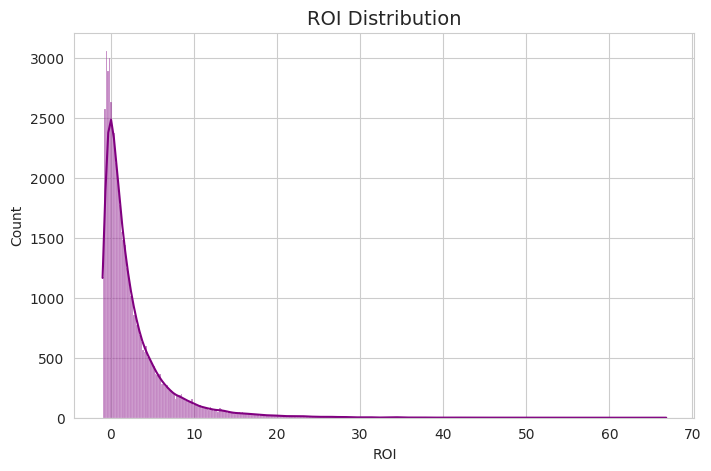

In [16]:
plt.figure()
sns.histplot(df["ROI"], kde=True, color="purple")
plt.title("ROI Distribution", fontsize=14)
plt.show()

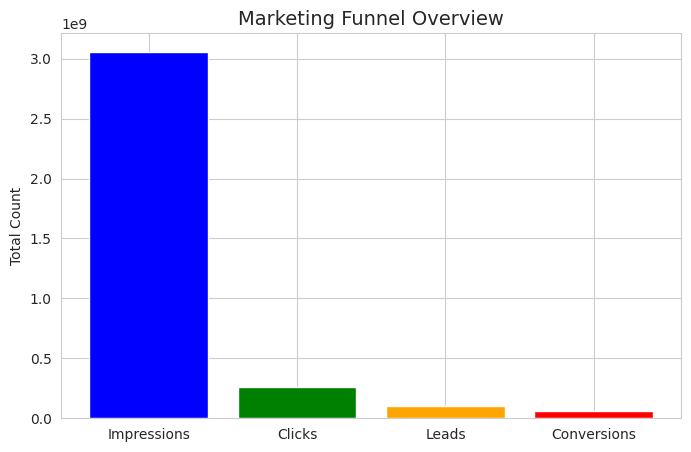

In [17]:
funnel_values = [
    df["Impressions"].sum(),
    df["Clicks"].sum(),
    df["Leads"].sum(),
    df["Conversions"].sum()
]

stages = ["Impressions", "Clicks", "Leads", "Conversions"]

plt.figure()
plt.bar(stages, funnel_values, 
        color=["blue", "green", "orange", "red"])
plt.title("Marketing Funnel Overview", fontsize=14)
plt.ylabel("Total Count")
plt.show()

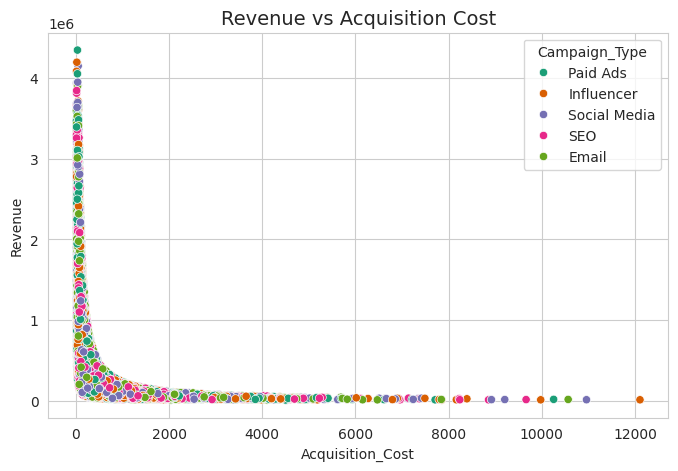

In [18]:
plt.figure()
sns.scatterplot(
    x="Acquisition_Cost",
    y="Revenue",
    hue="Campaign_Type",
    palette="Dark2",
    data=df
)
plt.title("Revenue vs Acquisition Cost", fontsize=14)
plt.show()

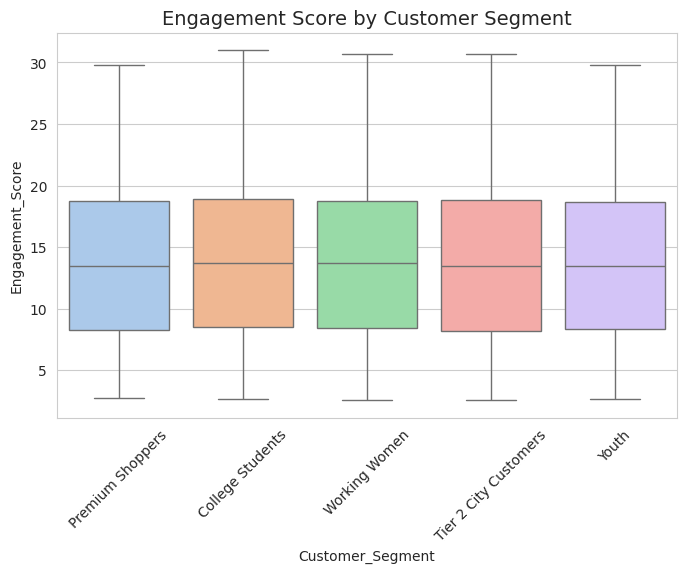

In [19]:
plt.figure()
sns.boxplot(
    x="Customer_Segment",
    y="Engagement_Score",
    data=df,
    palette="pastel"
)
plt.title("Engagement Score by Customer Segment", fontsize=14)
plt.xticks(rotation=45)
plt.show()

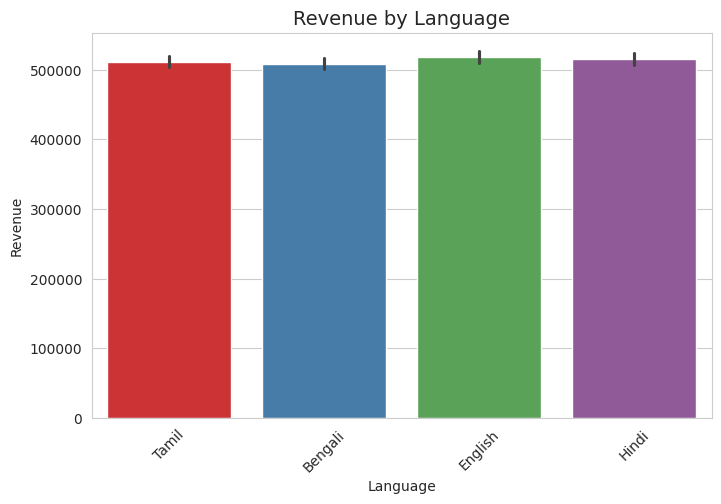

In [20]:
plt.figure()
sns.barplot(x="Language", y="Revenue", data=df, palette="Set1")
plt.title("Revenue by Language", fontsize=14)
plt.xticks(rotation=45)
plt.show()

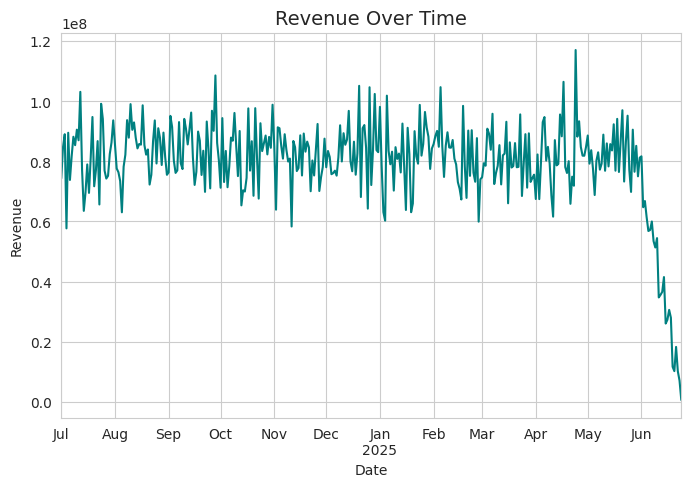

In [21]:
revenue_trend = df.groupby("Date")["Revenue"].sum()

plt.figure()
revenue_trend.plot(color="teal")
plt.title("Revenue Over Time", fontsize=14)
plt.ylabel("Revenue")
plt.show()

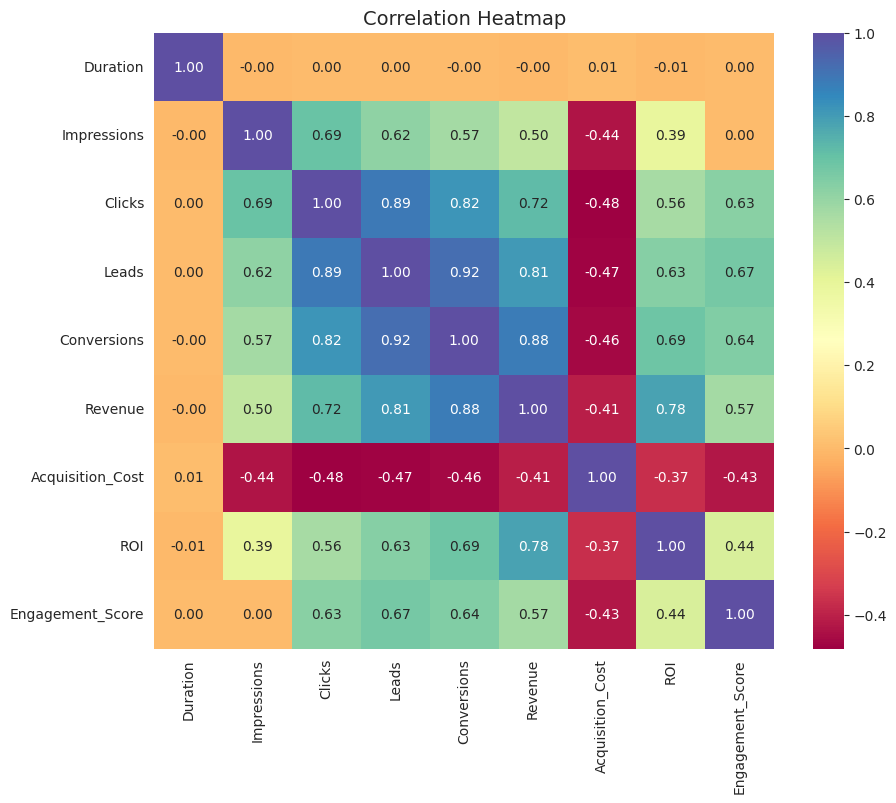

In [22]:
numeric_cols = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="Spectral", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

## Feature engineering

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [24]:
# Drop ID column
df = df.drop(columns=["Campaign_ID"], errors="ignore")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Extract useful date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df = df.drop(columns=["Date"])

# Fill missing numeric values
num_cols = df.select_dtypes(include=["int64","float64"]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [25]:
roi_median = df["ROI"].median()
df["High_ROI"] = np.where(df["ROI"] > roi_median, 1, 0)

# 🚨 Remove leakage columns
df = df.drop(columns=["ROI", "Revenue", "Conversions"], errors="ignore")

X = df.drop("High_ROI", axis=1)
y = df["High_ROI"]

print("Class Distribution:")
print(y.value_counts())


Class Distribution:
High_ROI
0    27854
1    27701
Name: count, dtype: int64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [27]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

In [29]:
results = {}

for name, model in models.items():
    
    pipe = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    
    print("\n==============================")
    print(name)
    print("Accuracy: {:.2f}%".format(acc))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 87.88%

Confusion Matrix:
[[4787  784]
 [ 563 4977]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88      5571
           1       0.86      0.90      0.88      5540

    accuracy                           0.88     11111
   macro avg       0.88      0.88      0.88     11111
weighted avg       0.88      0.88      0.88     11111


Random Forest
Accuracy: 87.76%

Confusion Matrix:
[[4775  796]
 [ 564 4976]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88      5571
           1       0.86      0.90      0.88      5540

    accuracy                           0.88     11111
   macro avg       0.88      0.88      0.88     11111
weighted avg       0.88      0.88      0.88     11111


SVM
Accuracy: 87.71%

Confusion Matrix:
[[4734  837]
 [ 528 5012]]

Classification Report:
              precision    recall  f1-score 

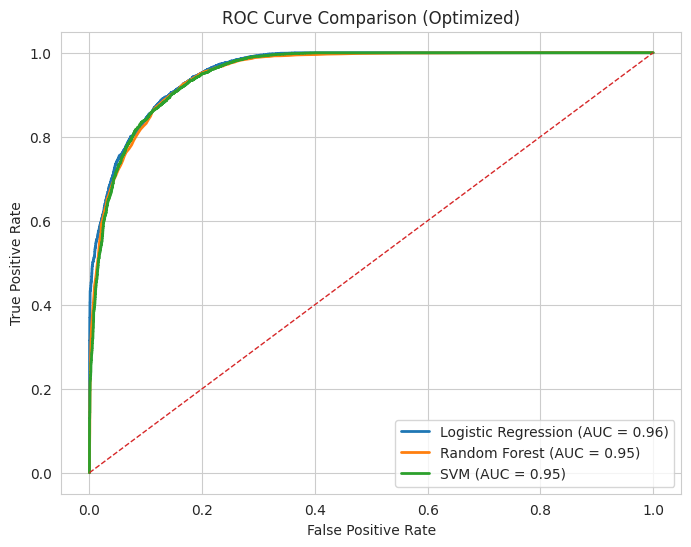

In [30]:
trained_pipes = {}

for name, model in models.items():
    
    pipe = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe


plt.figure(figsize=(8,6))

for name, pipe in trained_pipes.items():
    
    # Some models like SVM may not have predict_proba
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:,1]
    else:
        y_prob = pipe.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Optimized)")
plt.legend()
plt.grid(True)
plt.show()

## Thank you..pls upvote!!!!!1